In [47]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [48]:
X,y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

In [49]:
X

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

<Axes: >

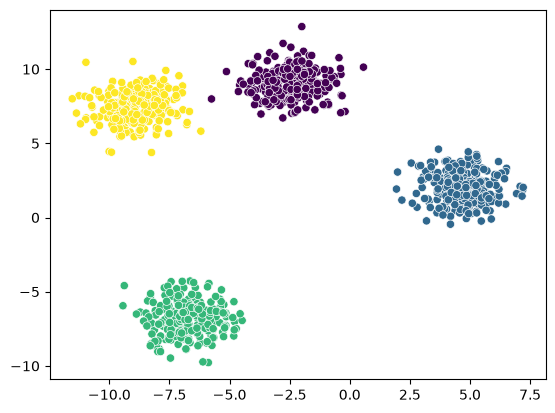

In [50]:
sns.scatterplot(x=X[:, 0],y=X[:, 1],c=y)

In [51]:
#k means clustering 
from sklearn.cluster import KMeans


In [52]:
k = 4

kmeans = KMeans(
    n_clusters = k,
    random_state=42
)

In [53]:
labels = kmeans.fit_predict(X)

In [54]:
labels

array([3, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 3, 0, 1, 1, 1, 0, 0, 0, 2, 2, 3,
       3, 3, 2, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 3, 1, 2, 3, 3, 2, 1, 2, 3,
       2, 3, 0, 2, 3, 2, 1, 0, 2, 3, 0, 3, 0, 0, 0, 1, 1, 0, 1, 3, 2, 0,
       1, 1, 2, 0, 3, 0, 2, 1, 2, 3, 2, 0, 2, 0, 1, 0, 0, 0, 2, 3, 1, 1,
       0, 0, 0, 0, 2, 2, 3, 2, 3, 0, 2, 1, 2, 3, 3, 0, 3, 2, 2, 0, 1, 0,
       3, 1, 2, 2, 2, 2, 1, 3, 1, 2, 0, 1, 3, 2, 3, 1, 2, 3, 1, 2, 0, 1,
       2, 3, 2, 3, 0, 1, 2, 2, 0, 0, 3, 3, 3, 2, 2, 0, 0, 0, 0, 3, 1, 1,
       0, 2, 0, 2, 2, 3, 1, 0, 2, 1, 0, 0, 2, 1, 3, 1, 2, 0, 0, 2, 0, 3,
       1, 3, 1, 3, 2, 2, 0, 1, 0, 1, 2, 3, 0, 1, 2, 0, 2, 2, 0, 3, 1, 1,
       1, 3, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 3, 1, 1, 2, 0, 1, 0, 3, 2,
       3, 3, 1, 0, 3, 0, 2, 1, 1, 0, 0, 1, 0, 3, 1, 1, 3, 1, 1, 2, 1, 3,
       1, 2, 3, 0, 2, 0, 2, 2, 2, 2, 3, 2, 2, 1, 0, 1, 1, 2, 2, 2, 3, 2,
       3, 3, 1, 2, 0, 3, 2, 0, 2, 1, 0, 3, 2, 3, 1, 2, 3, 1, 3, 2, 1, 0,
       0, 1, 0, 3, 3, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

<Axes: >

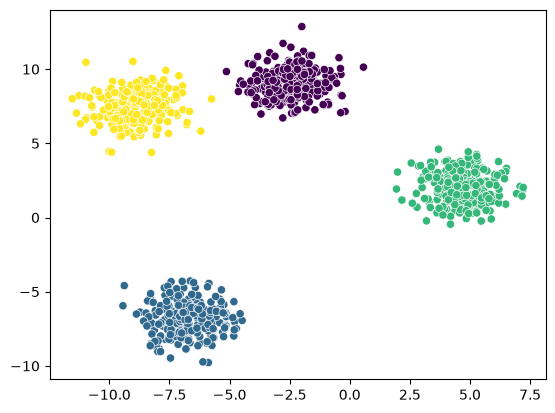

In [55]:
sns.scatterplot(x=X[:, 0],y=X[:, 1],c=labels)

In [56]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


# choose our k value - elbow;silhoutte score

In [57]:
# Elbow
wcss = []
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    

<Axes: >

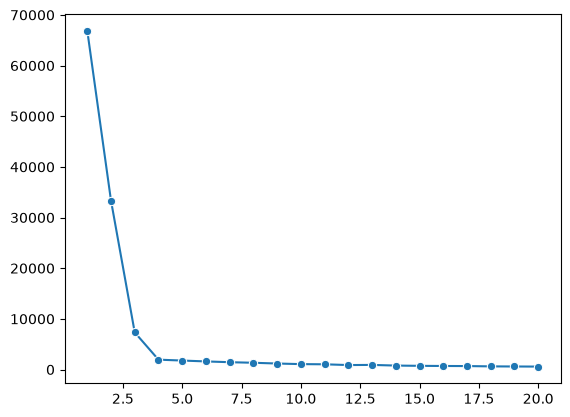

In [58]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')


In [59]:
# kneed module
from kneed import KneeLocator


In [60]:
knee = KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")

In [61]:
print("optimal K =",knee.elbow)

optimal K = 4


# silhoutte Score

In [62]:
from sklearn.metrics import silhouette_score 

In [63]:
ss = []

for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

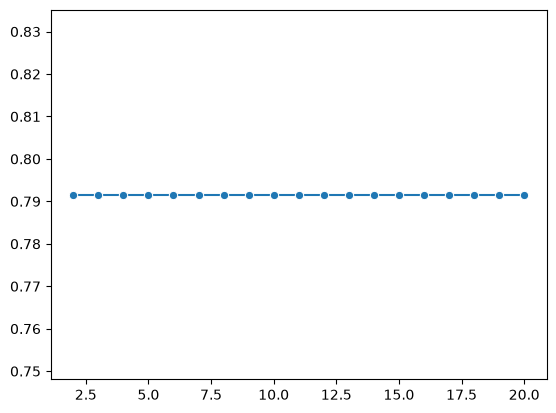

In [64]:
# plot k & ss
sns.lineplot(x=range(2,21),y=ss,marker='o')